### Import Relevant Libraries For Coding quiz


In [ ]:
%pip install --quiet --upgrade pip
%pip install opencv-python
%pip install --quiet --upgrade opencv-python

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import argparse
import json
import re
import seaborn as sns
import pandas as pd
import cv2


---

### **Coding Quiz: Autonomous Driving Perception Modules**
### **Duration: 4 hours**

**Instructions:**
1. This quiz contains 4 questions. Each question is designed to take approximately 1 hour.
2. Read each question carefully and ensure you understand the requirements and deliverables.
3. Write your Python code in the designated code cells. You can add more cells if needed.
4. Comment your code clearly to explain your logic.
5. For questions requiring image processing, you may use common libraries like OpenCV (`cv2`), NumPy, and Matplotlib. Sample images will be provided or described.
6. Focus on the core logic and algorithms. Full system optimization is not required.

---


#### **Question 1: Lane Detection Fundamentals**

**Background:** Lane detection is a critical component for ADAS. It involves identifying lane markings on the road from camera images. This question focuses on the fundamental image processing steps involved.

**Task:**
Write Python functions using OpenCV and NumPy to perform the following steps on a given road image:
1.  **Grayscale Conversion:** Convert the input color image to grayscale.
2.  **Gaussian Blur:** Apply Gaussian blur to the grayscale image to reduce noise (e.g., kernel size 5x5).
3.  **Canny Edge Detection:** Apply Canny edge detection to find prominent edges (e.g., low_threshold=50, high_threshold=150).
4.  **Region of Interest (ROI) Masking:** Define a polygonal (e.g., trapezoidal) ROI that focuses on the lane area in front of the vehicle. Apply this mask to the Canny edge output.
5.  **Hough Line Transform:** Apply the Hough Transform to the masked edges to detect lines. (Focus on `HoughLinesP` for line segments).
6.  **Lane Line Averaging/Extrapolation (Conceptual):** Briefly explain in a markdown cell how you would process the lines detected by the Hough Transform to identify and represent the left and right lane lines (e.g., averaging slope/intercept, fitting a line to points).

**Hints:**
- Use `cv2.cvtColor()`, `cv2.GaussianBlur()`, `cv2.Canny()`, `cv2.fillPoly()` (for ROI), `cv2.HoughLinesP()`.
- For the ROI, you'll need to define vertices based on image dimensions. Assume a standard forward-facing camera perspective.
- You can use a sample road image (e.g., load one from a URL or a local path if provided, or create a simple synthetic one with lines for testing). You can name it `road_sample.jpg`.

**Deliverables:**
- Python code implementing functions for steps 1-5.
- A main script block that loads a sample image (`road_sample.jpg`), applies these functions sequentially, and displays the original image and the final image with detected Hough lines overlaid (or the masked Canny edges if line drawing is complex).
- A markdown cell explaining step 6.


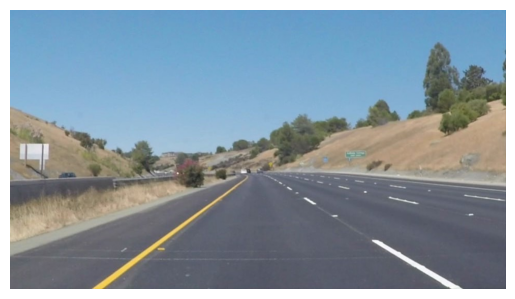

------------------------------------------------------------


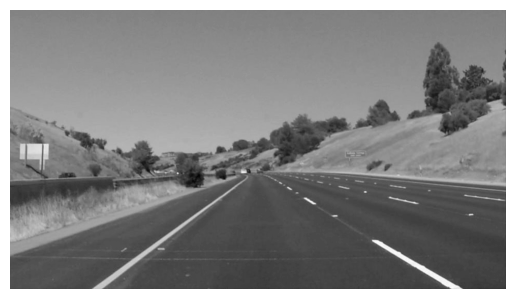

------------------------------------------------------------


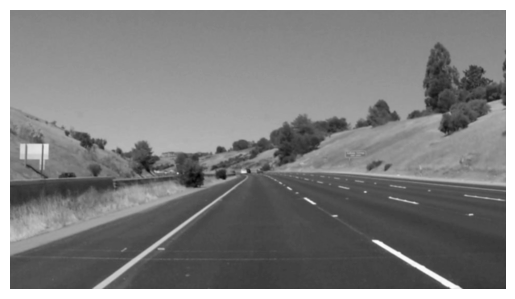

------------------------------------------------------------


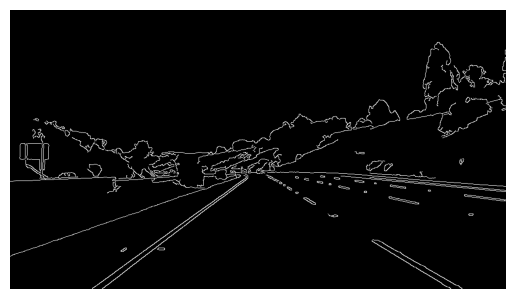

Edges image shape: (540, 960)
Image Dimensions: height:540, width: 960
Roi_vertices shape: [[[  0 540]
  [430 320]
  [530 320]
  [960 540]]]
------------------------------------------------------------


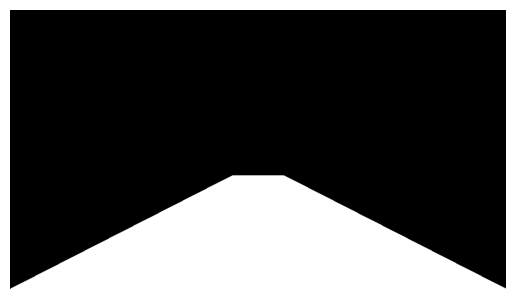

------------------------------------------------------------


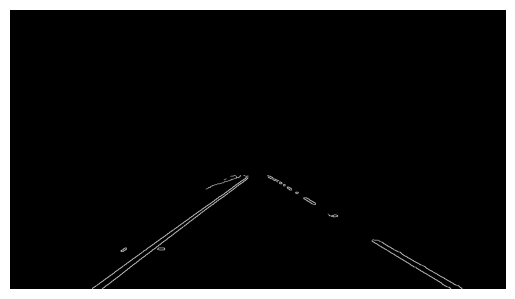

------------------------------------------------------------


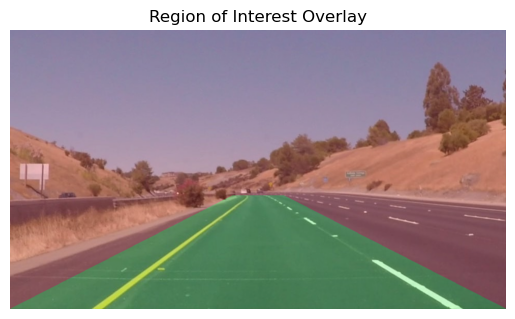

------------------------------------------------------------


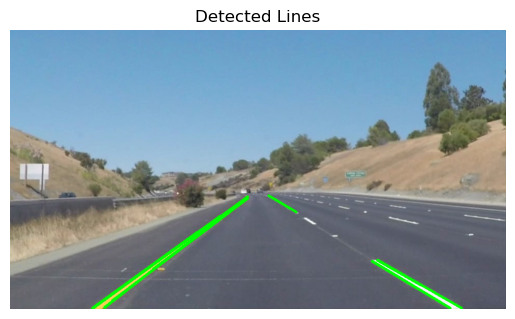

Final image with detected lines saved as: detected_lines_output.jpg
------------------------------------------------------------


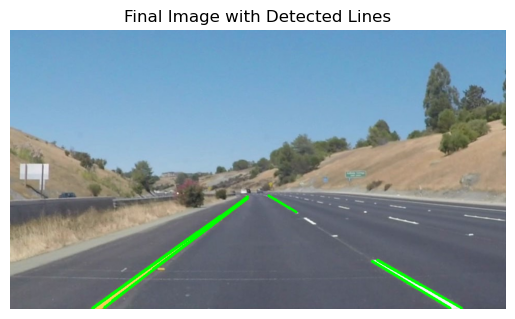

In [52]:
import cv2

# Replace 'road_sample.jpg' with your image filename (make sure it's in the same folder as your notebook)
image = cv2.imread(r'C:\Users\Taber\Desktop\Nutt_KMUTT_folder\lane_detect_source.jpg')

# Check if the image loaded successfully
if image is None:
    print("Image not found or path is incorrect.")
else:
    # Convert BGR (OpenCV default) to RGB for display with matplotlib
    import matplotlib.pyplot as plt
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()

# Step 1: Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#show the grayscale image
#print(f"Grayscale image shape: {gray.shape}")
#print(f"apply grayscale to image")
print(f"------------------------------------------------------------")
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()
# Step 2: Apply Gaussian Blur
blurred = cv2.GaussianBlur(gray, (3, 3), 0)
#show the blurred image
#print(f"apply Gaussian Blur to image")
print(f"------------------------------------------------------------")
plt.imshow(blurred, cmap='gray')
plt.axis('off')
plt.show()
# Step 3; Canny edge detection
edges = cv2.Canny(blurred, 50, 150)
#show the edges
#print(f"apply Canny edge detection to image")
print(f"------------------------------------------------------------")
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()
#shape of the edges image
print(f"Edges image shape: {edges.shape}")
# Step 4 Apply Region of interest (ROI) Masking
# Define the trapezoidal region of interest
# Define the vertices of the trapezoid
height, width = edges.shape
#ROI_img = cv2.fillPoly(edges,)

#format setting (x, y) coordinates
bottom_left = (0, height)
top_left = (width // 2 - 50, height // 2 + 50)
top_right = (width // 2 + 50, height // 2 + 50)
bottom_right = (width, height)

#Concat together ther vertice
Roi_vertices = np.array([[bottom_left, top_left, top_right, bottom_right]], dtype=np.int32)
#let check the shape of the vertices and image
print (f"Image Dimensions: height:{height}, width: {width}")
print(f"Roi_vertices shape: {Roi_vertices}")

# Create a mask for the region of interest(by black the images)
mask = np.zeros_like(edges)

# Fill the mask with the trapezoidal region
cv2.fillPoly(mask, Roi_vertices, 85)
#show the mask
print(f"------------------------------------------------------------")
plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()

# apply the mask to the edges image
roi_edges = cv2.bitwise_and(edges, mask)
#show the roi edges
print(f"------------------------------------------------------------")
plt.imshow(roi_edges, cmap='gray')  
plt.axis('off')
plt.show()

#further more Visualization the ROI pm a colored image
color_background = np.zeros((height, width, 3), dtype=np.uint8)
# Fill the trapezoidal region with a color (e.g., blue)
color_background[:,:] = [0, 0, 255]  # Blue color
# create a transparent overlay
roi_overlay = color_background.copy()
cv2.fillPoly(roi_overlay, Roi_vertices, (0, 255, 0))  # Green color for the ROI
# Combine the original image with the overlay
overlayed_image = cv2.addWeighted(image, 0.8, roi_overlay, 0.2, 0)
# Show the overlayed image
print(f"------------------------------------------------------------")
plt.imshow(cv2.cvtColor(overlayed_image, cv2.COLOR_BGR2RGB))
plt.title('Region of Interest Overlay')
plt.axis('off')
plt.show()
#step 5: Hough Transform to detect lines

lines = cv2.HoughLinesP(roi_edges, 1, np.pi / 180, threshold=50, minLineLength=50, maxLineGap=10)
# Draw the detected lines on the original image
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(image, (x1, y1), (x2, y2), (0, 255, 0), 3)  # Draw green lines
    # Show the image with detected lines
    print(f"------------------------------------------------------------")
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Detected Lines')
    plt.axis('off')
    plt.show()
else:
    print("No lines were detected.")
# Save the final image with detected lines
output_path = 'detected_lines_output.jpg'
cv2.imwrite(output_path, image)
print(f"Final image with detected lines saved as: {output_path}")
# Display the final image with detected lines
print(f"------------------------------------------------------------")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Final Image with Detected Lines')
plt.axis('off')
plt.show()



#### **Question 1 - Step 6: Lane Line Averaging/Extrapolation Explanation**

*(Student: Write your explanation here. Consider the following points:)*
-   How to distinguish left and right lane lines from the Hough segments (e.g., based on slope, position)?
-   How to handle multiple segments that belong to the same lane line?
-   How to represent the final left and right lanes (e.g., as two distinct lines with averaged slope/intercept, or by fitting a polynomial)?
-   How to extrapolate these lines to a desired length or within the ROI?

---
#### **Question 2: Vehicle Detection using a Pre-trained Model**

**Background:** Vehicle detection identifies the location and class of vehicles in an image. Modern detectors are often based on Deep Learning.

**Task:**
Write a Python script to:
1.  Load a pre-trained object detection model capable of detecting vehicles (e.g., from `torchvision.models.detection` like Faster R-CNN or SSD. For simplicity, `torchvision` is recommended).
2.  Load a sample image containing vehicles (e.g., `vehicles_sample.jpg`).
3.  Perform inference using the model to get detections (bounding boxes, labels, scores).
4.  Filter the detections to keep only vehicles (e.g., 'car', 'truck', 'bus') with a confidence score above a certain threshold (e.g., 0.5).
5.  Draw the bounding boxes and labels for the detected vehicles on the original image.

**Hints:**
-   If using `torchvision.models.detection`, explore models like `fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)` or `ssd300_vgg16(weights=SSD300_VGG16_Weights.DEFAULT)`.
-   Remember to preprocess the input image as required by the chosen model (e.g., convert to tensor, normalize).
-   The output of these models typically includes boxes (coordinates), labels (class IDs), and scores. You'll need to map class IDs to human-readable names (COCO dataset class names are common and provided in the starter code).
-   Use `cv2.rectangle()` and `cv2.putText()` to draw on the image.

**Deliverables:**
- Python code for loading the model, performing inference, filtering, and visualization.
- The output image with detected vehicles clearly marked.


NameError: name 'ff' is not defined

---
#### **Question 3: Vehicle Tracking Concepts (DeepSORT Interaction)**

**Background:** Vehicle tracking assigns a consistent ID to detected vehicles across frames. DeepSORT is a common algorithm that combines motion (Kalman Filter, Hungarian algorithm for association) and appearance features (from a Re-ID network) for robust tracking.

**Task:**
This question focuses on the conceptual interaction with a tracker like DeepSORT, not its full implementation.
1.  **Tracker Update Function (Conceptual):** Write a Python function `update_tracker_conceptual(current_detections, deep_sort_tracker_placeholder)`.
    * `current_detections`: Assume this is a list of tuples, where each tuple is `(bbox, confidence, class_name, feature_vector)`. `bbox` is `[x1, y1, x2, y2]`. `feature_vector` is a placeholder for an appearance feature from a Re-ID network (you can use a small random NumPy array, e.g., `np.random.rand(1,128)`).
    * `deep_sort_tracker_placeholder`: This is a *conceptual* placeholder for an actual DeepSORT tracker object. Your function's primary role is to describe, using detailed comments and perhaps some pseudo-code or simplified placeholder calls, how you would interact with a real DeepSORT tracker's `update` method. Explain the main steps you expect a DeepSORT `update` method to internally perform based on the `current_detections`:
        * Prediction: How existing tracks are predicted forward (e.g., Kalman Filter prediction step).
        * Association: How current detections are matched with predicted tracks (mention motion, appearance, and the role of the Hungarian algorithm).
        * Update: How matched tracks are updated (e.g., Kalman Filter update step).
        * Track Management: How unmatched detections (new tracks) and unmatched tracks (potential deletions) are handled.
    * The function should conceptually return a list of `tracked_objects`. Each `tracked_object` could be a dictionary like `{'id': track_id, 'bbox': updated_bbox, 'class_name': class_name}`.

2.  **Data Association (Simplified IoU Scenario):**
    Imagine you have:
    * Two existing tracks from the previous frame: 
        * `track1 = {'id': 1, 'predicted_bbox': [100, 100, 150, 150]}`
        * `track2 = {'id': 2, 'predicted_bbox': [300, 100, 350, 150]}`
    * Three new detections in the current frame:
        * `detectionA = {'bbox': [105, 102, 155, 152]}`
        * `detectionB = {'bbox': [200, 110, 250, 160]}` (designed to not overlap much with track1 or track2)
        * `detectionC = {'bbox': [302, 103, 352, 153]}`
    Write a Python snippet to calculate the Intersection over Union (IoU) between each track's `predicted_bbox` and each `detection`'s `bbox`. 
    Based *only* on IoU, describe which detection would likely be associated with which track if using a simple IoU-based matching strategy (e.g., highest IoU above a threshold for each track, ensuring unique assignments if possible). Explain the role of the Hungarian algorithm in a more complete association scenario where multiple tracks could match multiple detections with varying costs.

**Hints:**
- For part 1, focus on the logical flow and data structures. You don't need to implement Kalman Filters or Hungarian algorithm. Think about what information DeepSORT needs and what it provides. The `DeepSORTTrackerPlaceholder` class is provided as a conceptual aid.
- For part 2, implement a standard IoU calculation function. The Hungarian algorithm solves the assignment problem optimally when you have a cost matrix (e.g., based on IoU or other distances).

**Deliverables:**
- Python function `update_tracker_conceptual` with detailed comments explaining the conceptual interaction with a DeepSORT-like process.
- Python snippet for IoU calculation and the explanation for the simplified data association scenario, including the role of the Hungarian algorithm.


#### **Student Explanation for Q3 Part 2 (IoU Association & Hungarian Algorithm)**

*(Student: Write your explanation here based on your IoU calculations if implemented.)*

**Simplified IoU-based association description:**
- Track 1 would likely be associated with Detection ... because ...
- Track 2 would likely be associated with Detection ... because ...
- Detection B would likely be considered ... because ...

**Role of the Hungarian Algorithm:**
- In a more complex scenario with many tracks and detections...
- It takes a cost matrix ... and finds ...
- This ensures optimal assignment when ...

---
#### **Question 4: Data Fusion & Simple Lane Change Logic**

**Background:** Data fusion combines information from multiple sensors or modules to make informed decisions. Here, we'll fuse lane information and tracked vehicle information for a simple lane change assessment.

**Task:**
Write a Python function `assess_lane_change(vehicle_track, left_lane_line, right_lane_line, image_width)` that determines if a tracked vehicle might be initiating a lane change.

**Inputs to your function:**
1.  `vehicle_track`: A dictionary representing a tracked vehicle, e.g., 
    `{'id': 1, 'bbox': [x1, y1, x2, y2], 'history_bboxes': [[x1_prev, y1_prev, x2_prev, y2_prev], ...]}`.
    `history_bboxes` contains bounding boxes from the last few frames (e.g., 2-3 previous frames).
2.  `left_lane_line`: A tuple `(x1_left, y1_left, x2_left, y2_left)` representing the detected left lane line segment relevant to the vehicle's vertical position. Assume `y1` is the 'upper' y-coordinate and `y2` is the 'lower' y-coordinate of the segment.
3.  `right_lane_line`: A tuple `(x1_right, y1_right, x2_right, y2_right)` for the right lane line.
4.  `image_width`: The width of the image, used to understand scale.

**Logic to implement within `assess_lane_change`:**
1.  Calculate the horizontal center of the `vehicle_track`'s current bounding box: `current_vehicle_center_x = (x1 + x2) / 2`. Also find `current_vehicle_center_y = (y1 + y2) / 2`.
2.  Estimate the x-coordinates of the left and right lane lines at the `current_vehicle_center_y`. You can use a helper function for linear interpolation given a line segment and a y-value. Handle cases where `current_vehicle_center_y` might be outside the y-range of the provided lane segments (e.g., by clamping or using endpoint x values).
3.  Assess lateral movement: Compare `current_vehicle_center_x` with the average horizontal center from `history_bboxes`. Determine if there's a consistent lateral movement (e.g., `movement_trend = -1` for left, `1` for right, `0` for stable/none).
4.  Proximity to lane lines: Calculate the vehicle's proximity to the estimated `est_left_lane_x` and `est_right_lane_x` at its `current_vehicle_center_y`. Is the vehicle's current bounding box edge (e.g., `x1` or `x2`) very close to or crossing one of these estimated lane x-positions? Define a reasonable proximity threshold (e.g., a percentage of the estimated lane width at that y-level, or a fixed pixel value).
5.  Based on a combination of `lateral_movement_trend` and `proximity/crossing` status, return a string: 
    `'LANE_KEEPING'`, `'INITIATING_LEFT_LANE_CHANGE'`, `'INITIATING_RIGHT_LANE_CHANGE'`, or `'UNCERTAIN'`.

**Hints:**
- The `get_x_at_y(line_segment, target_y)` helper function for interpolation will be useful.
- Define clear thresholds for 'significant movement' and 'proximity'.
- Focus on a rule-based approach for the decision logic. Clearly state your rules in comments.

**Deliverables:**
- Python code for the `assess_lane_change` function and any helper functions (like `get_x_at_y`).
- Example calls to your function demonstrating at least three different scenarios (e.g., vehicle keeping lane, vehicle clearly moving left towards line, vehicle crossing right line) and print the returned status. Clearly define your input `vehicle_track`, `left_lane_line`, etc., for each scenario.


---
**End of Quiz**

Ensure all your code cells are filled where required and any markdown explanations are complete. Save and submit your notebook.